<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/data_driven_toy_sine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data-Driven Modeling of a Sine Function

This notebook demonstrates the core functionality of the Data-Driven module using a simple analytical sine function as a toy model. The goal is to approximate a known function:

$$
y = a \sin(bt + c)
$$

using machine learning techniques based on synthetic data. The input parameters $\mathbf{x} = [a, b, c]^T$ are sampled from predefined distributions, and the outputs $\mathbf{y}$ are computed at $N=9$ discrete time steps. Gaussian noise is added to simulate observational uncertainty.

A **gPCE (Generalized Polynomial Chaos Expansion)** model is trained to approximate the mapping from input parameters to function outputs.

**Sensitivity analyses** using Sobol indices are performed to assess the global influence of each input parameter on the response.

**SHAP (SHapley Additive exPlanations)** values are computed to explain the contributions of individual input features on model predictions.

The **effects** of input parameters are isolated and subtracted from the model response to better understand their influence.


# Imports

In [ ]:
!pip install digital_twinning

In [4]:
import sys
import os
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import digital_twinning
import digital_twinning.utils as utils
import uncertain_variables as uv
import pandas as pd
import numpy as np
import requests

# Load data

In [5]:
data_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/sine/'
x_df = pd.read_csv(data_path + 'example_x_df.csv')
y_df = pd.read_csv(data_path + 'example_y_df.csv')

### For training and sensitivity analysis

In [6]:
Q = utils.get_variableset_from_data(x_df)
QoI_names = y_df.columns.to_list()

max_index = 2
QoI_param = 't_3'

subtracted_effects = ['a','b','c']

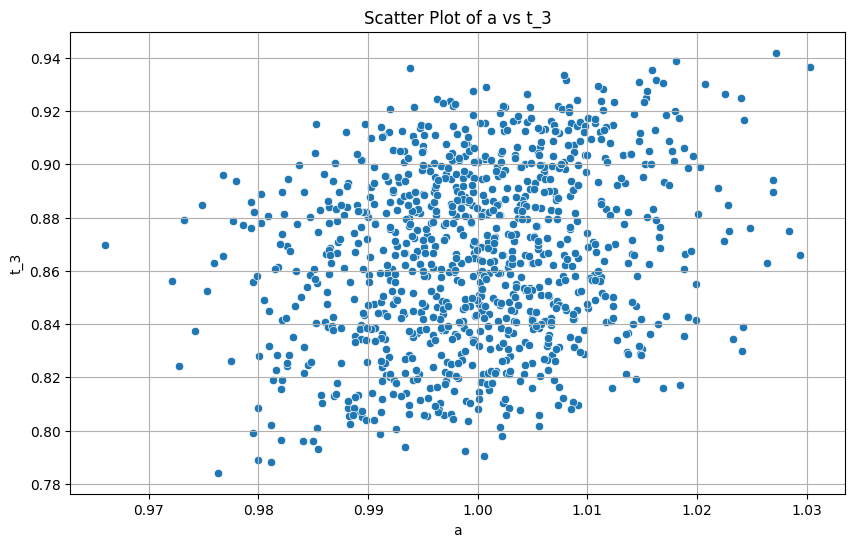

In [7]:
fig = digital_twinning.scatter_plot(x_df, y_df, 'a', QoI_param)

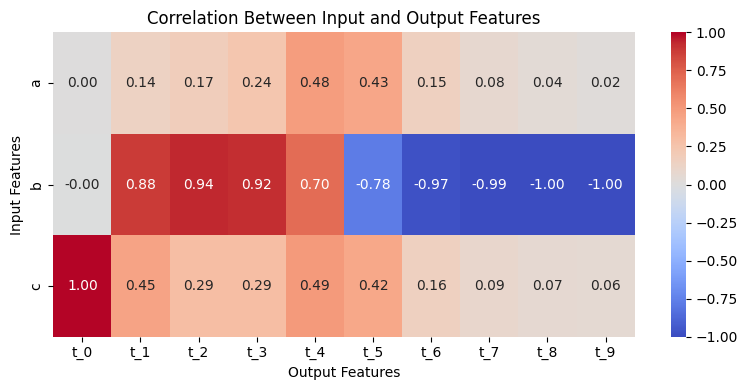

In [8]:
fig = digital_twinning.plot_correlation(x_df, y_df, mode='input-output')

### For measurements

In [9]:
z_m_df = pd.read_csv(data_path + 'example_z_m_df.csv')
sigma = pd.read_csv(data_path + 'example_sigma_df.csv')

### For update

In [10]:
nwalkers = 64
nburn = 800
niter = 200

E = uv.generate_stndrn_variable_set(sigma.values.reshape(-1, 1))

r = requests.get(data_path + 'example_q.npy')
r.raise_for_status()

with open("example_q.npy", "wb") as f:
    f.write(r.content)

q = np.load('example_q.npy')
q_df = pd.read_csv(data_path + 'example_q_df.csv')

# Train model

### Choosing the Model

In this notebook, we implement the model using one of the following methods: **gPCE**, **DNN**, **GBT**, or **LinReg**.

* **gPCE (Generalized Polynomial Chaos Expansion)**: Models uncertainty by expressing the output as a polynomial expansion, with coefficients determined by projecting the system's response onto orthogonal polynomials.

* **DNN (Deep Neural Networks)**: Machine learning models composed of interconnected neurons, capable of learning complex, non-linear patterns from data.

* **GBT (Gradient Boosting Trees)**: Combines weak decision trees into a strong predictive model, iteratively correcting errors from previous trees for robust performance.

* **LinReg (Linear Regression)**: A statistical method that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data.

In [11]:
method = "gPCE"

In [12]:
# Model configurations
match method:
    # DNN model configurations
    case "DNN":
        config = {
            'init_config' : {
                'layers': [
                    {'neurons': 512, 'activation': 'relu', 'dropout': 0.2},
                    {'neurons': 256, 'activation': 'sigmoid', 'dropout': 0.2},
                    {'neurons': 128, 'activation': 'relu', 'dropout': None},
                    ],
                'outputAF': 'tanh'
                },
            'train_config' : {
                'optimizer': 'Adam',
                'loss': 'MSE',
                'epochs': 100,
                'batch_size': 32,
                'k_fold': None,
                'early_stopping': {
                    'patience': 25,
                    'min_delta': 0.0001}
                }
                }
    # gPCE model configurations
    case "gPCE":
        config = {
            'init_config' : {
            'p' : 5
            },
            'train_config' : {
                'k_fold': 5
                }
        }
    # GBT model configurations
    case "GBT":
        config = {
            'init_config' : {
                'gbt_method': 'xgboost'
            },
            'train_config' : {
                'max_depth': 3,
                'num_of_iter': 250,
                'k_fold': 5
                }
        }
    # LinReg model configurations
    case "LinReg":
        config = {
            'init_config' : {
            },
            'train_config' : {
                'k_fold': 5
                }
        }

split_config = {
        'train_test_ratio': 0.8,
        'random_seed': 1997,
        'split_type': 'no_shuffle'
        }

In [13]:
# Initialize surrogate model
# This creates an instance of the SurrogateModel class using the provided sampling data (Q)
model = digital_twinning.DataDrivenModel(Q, QoI_names, method, **config['init_config'])
# Split data into training and testing sets
X_train, X_test, y_train, y_test = model.train_test_split(x_df, y_df, **split_config)
# Train the model
model.train(X_train, y_train, **config['train_config'])

----- Training started for 'gPCE' model -----
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Average train loss: 0.00000000000000, Average valid loss: 0.00000000000000
----- Training ended for 'gPCE' model -----


In [14]:
# get mean and variance of surrogate model
mean, var = model.get_mean_and_var()
mean, var

(array([5.79041497e-04, 3.42488998e-01, 6.42767984e-01, 8.64918787e-01,
        9.82070852e-01, 9.80272399e-01, 8.60173356e-01, 6.36893538e-01,
        3.38098696e-01, 5.31712869e-04]),
 array([9.71924556e-05, 4.66154378e-04, 1.08746733e-03, 1.08159967e-03,
        3.94454512e-04, 5.14724359e-04, 3.81450969e-03, 1.16757929e-02,
        2.26557371e-02, 3.22575300e-02]))

## Sobol sensitivities

In [15]:
# set max_index for Sobol sensitivity analysis
max_index = 2
partial_variance, sobol_index = model.get_sobol_sensitivity(max_index)

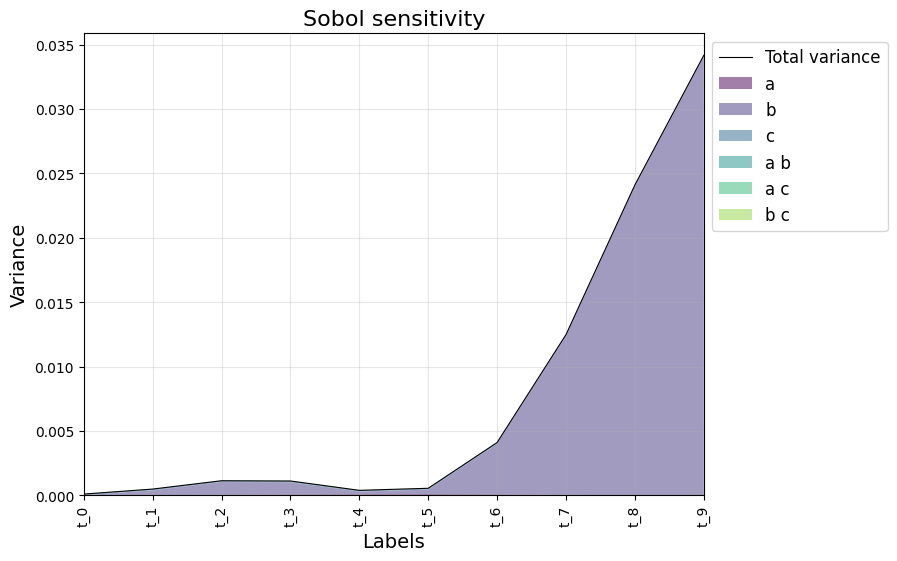

In [16]:
# Plot Sobol Sensitivity Index
# The 'plot_sobol_sensitivity' method generates a plot of Sobol Sensitivity indices, which quantify
# the contribution of each input parameter to the output uncertainty.
# - max_index: Specifies the maximum index of parameters to consider in the plot.
# - param_name: The name of the quantity of interest (QoI) for which sensitivity is being calculated ('t_3' in this case).
fig = model.plot_sobol_sensitivity(y_train)

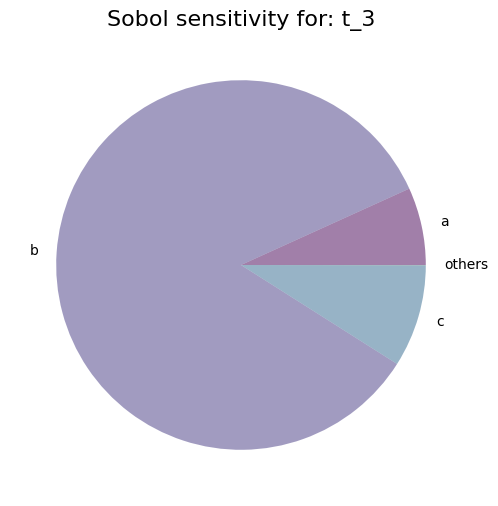

In [17]:
fig = model.plot_sobol_sensitivity(y_train, max_index=max_index, param_name=QoI_param)

## SHAP values

In [18]:
# Calculate SHAP (Shapley Additive Explanations) values
# The 'get_shap_values' method computes the SHAP values for the model's test data (model.X_test).
# SHAP values explain the contribution of each input feature to the prediction for each test sample.
# SHAP values help to interpret the model's decisions and understand the impact of each input parameter on the output.
shap_values = await model.get_shap_values(X_test, silent=True)

Message: sample size for shap values is set to 100.


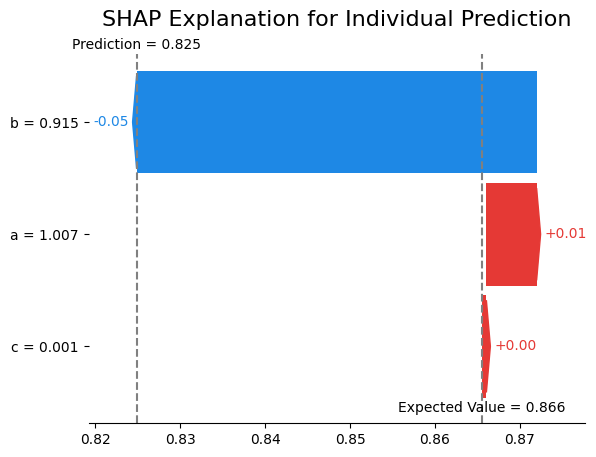

In [19]:
# Plot SHAP Single Waterfall Plot
# The 'plot_shap_single_waterfall' method generates a SHAP waterfall plot for a single test sample,
# visualizing how each feature contributes to the model's prediction for that sample.
# - q: A DataFrame containing the sample data (e.g., a specific parameter set) for which the SHAP values are calculated.
# - param_name: The name of the quantity of interest (QoI) being analyzed ('t_3' in this case).
# The SHAP waterfall plot shows the cumulative effect of each feature on the model's prediction, helping to interpret individual predictions.
fig = await model.plot_shap_single_waterfall(X_test, q=q_df, param_name=QoI_param, silent=True)

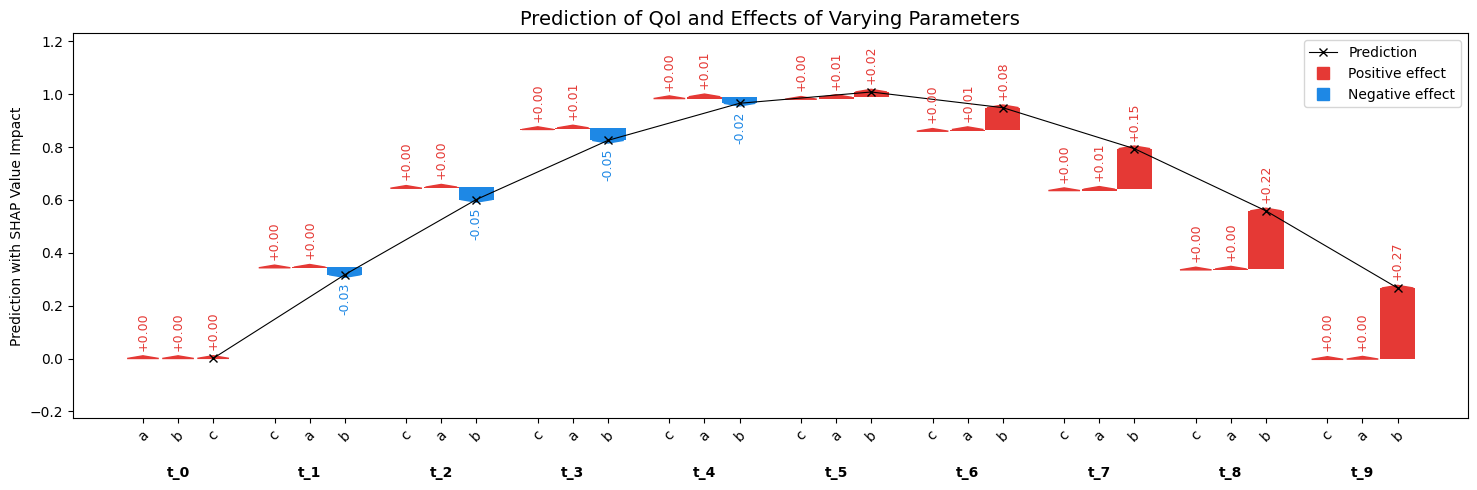

In [20]:
fig = await model.plot_shap_multiple_waterfalls(X_test, q=q_df, silent=True)

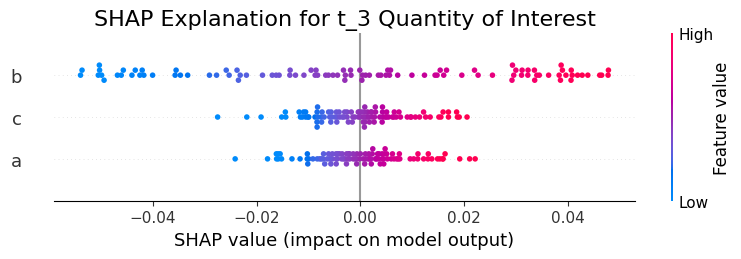

In [21]:
# Plot SHAP Beeswarm Plot
# The 'plot_shap_beeswarm' method generates a SHAP beeswarm plot, which visualizes the distribution of SHAP values
# for a range of test samples, showing the impact of each feature on the model’s predictions.
# - q: The test data (model.X_test.iloc[:100]) is selected for which SHAP values are calculated and visualized.
# - param_name: The name of the quantity of interest (QoI) for which SHAP values are computed ('t_3' in this case).
# The SHAP beeswarm plot shows how different input features influence the predictions across multiple samples,
# helping to understand the global feature importance and the relationships between features and the target.
fig = await model.plot_shap_beeswarm(X_test, param_name=QoI_param, silent=True)

## Effects

Message: sample size for shap values is set to 100, which is the number of samples.


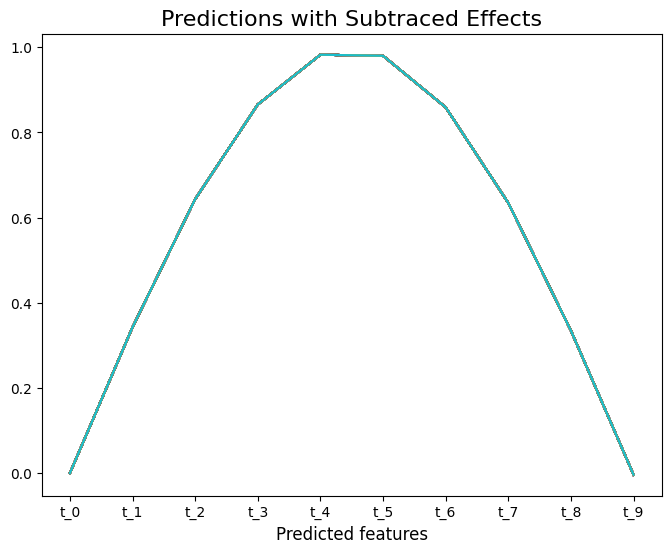

In [22]:
effects = await model.subtract_effects(X_test.iloc[:100], y_test.iloc[:100], subtracted_effects, silent=True)
fig = await model.plot_effects(effects)

Message: sample size for shap values is set to 800, which is the number of samples.
Message: sample size for shap values is set to 1, which is the number of samples.


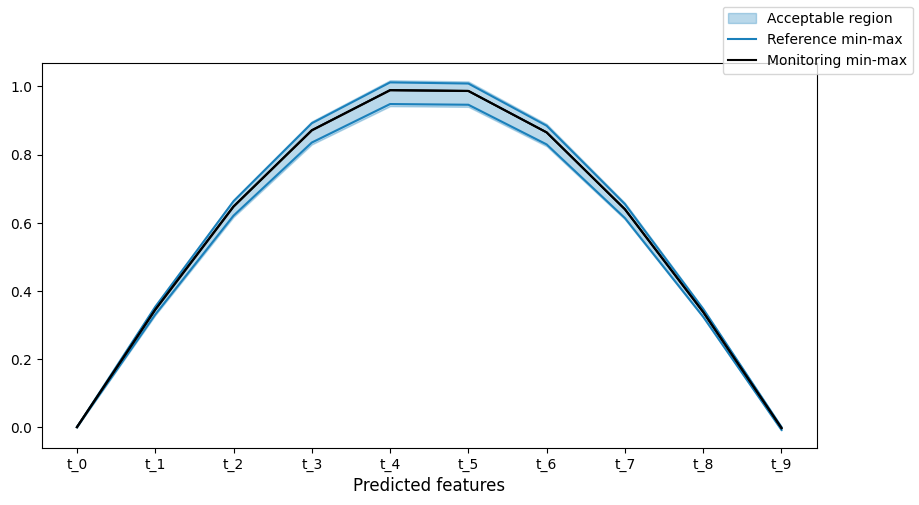

In [23]:
fig, alert, remained_effects_df, error_ratio, problematic_rows, reference_statistics, monitoring_statistics = await model.plot_subtract_effects_and_alert(X_train, y_train, q_df, z_m_df, subtracted_effects[1:], silent=True)